In [1]:
!pip install -Uqq fastbook

In [2]:
import fastbook
fastbook.setup_book()

In [3]:
from fastbook import *

In [4]:
params = torch.randn(3).requires_grad_(); params

tensor([0.3367, 0.1288, 0.2345], requires_grad=True)

In [5]:
time = torch.arange(0, 20).float(); time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

In [6]:
speed = 3*torch.rand(20) + (0.75*(time-9.5))**2 + 1; speed

tensor([54.5879, 42.0402, 35.4444, 26.5464, 20.6238, 14.0938, 10.1139,  5.8038,  4.9220,  2.8623,  1.9404,  4.1480,  5.3245,  9.2147, 13.2814, 20.5107, 25.0816, 33.4491, 42.7171, 52.3637])

In [7]:
def f(t, params):
    a, b, c = params
    return a*(t**2) + b*t + c

In [8]:
preds = f(time, params)
preds

tensor([  0.2345,   0.7000,   1.8388,   3.6511,   6.1367,   9.2958,  13.1282,  17.6340,  22.8131,  28.6657,  35.1916,  42.3909,  50.2636,  58.8097,  68.0291,  77.9219,  88.4881,  99.7277, 111.6407,
        124.2271], grad_fn=<AddBackward0>)

In [14]:
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

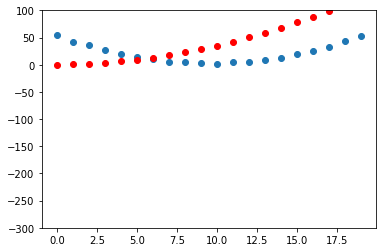

In [15]:
show_preds(preds)

In [16]:
def mse(preds, target): return ((preds-target)**2).mean()

In [17]:
loss = mse(preds, speed)
loss

tensor(1967.6725, grad_fn=<MeanBackward0>)

In [18]:
loss.backward()

In [19]:
lr = 1e-5
params.data -= params.grad.data * lr
params.grad = None

In [20]:
def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= params.grad.data * lr
    params.grad = None
    print(loss.item())
    show_preds(preds)

687.4456176757812


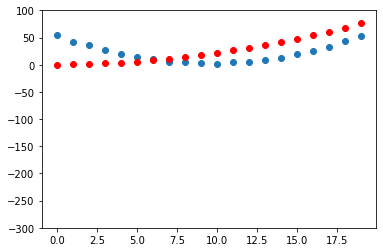

In [21]:
apply_step(params)

445.18560791015625


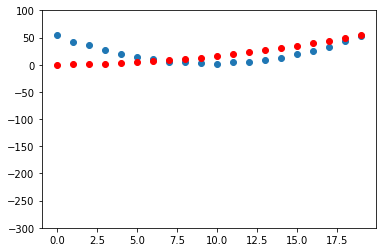

In [22]:
apply_step(params)

399.3406982421875
390.66363525390625
389.01971435546875
388.7068176269531
388.6456604003906
388.63226318359375
388.62786865234375
388.6251525878906
388.6226806640625
388.6203918457031


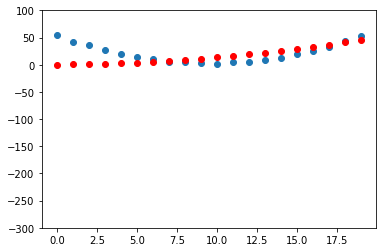

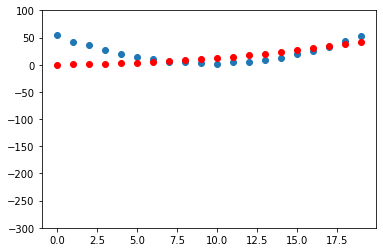

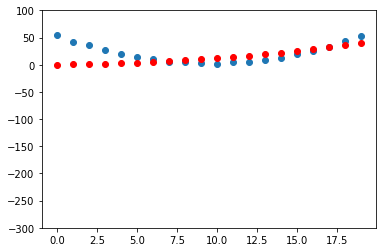

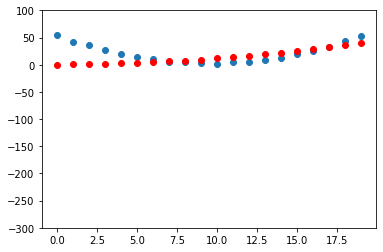

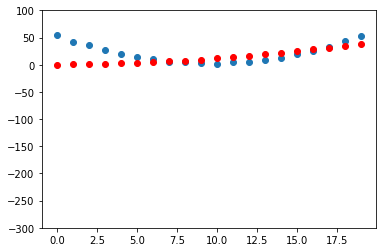

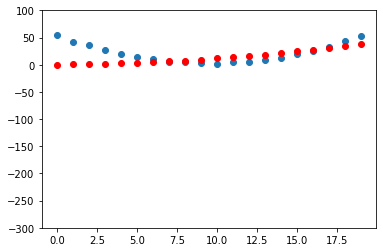

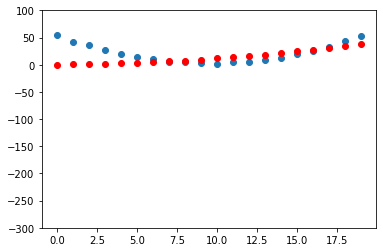

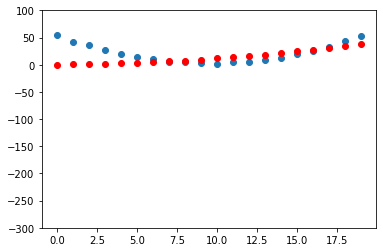

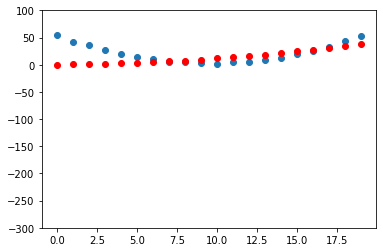

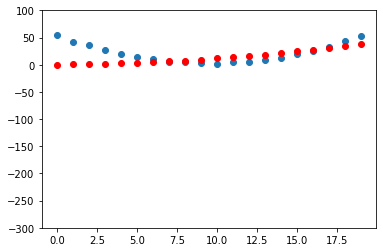

In [23]:
for i in range(10):
    apply_step(params)